# Furniture Sales Data Analysis Report
**Dataset:** Furniture2.csv (2,500 records, 13 columns)  
**Sections:** Overview → Category/Material → Season/Location → Store Type → Profit → Inventory Risk → Delivery → Correlation → Summary

In [1]:
# ============================================================
# Step 1: Import all libraries & global settings
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Visualization style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

## 1. Data Overview

In [2]:
# ============================================================
# Step 2: Load dataset
# ============================================================
df = pd.read_csv('Furniture2.csv')

print(f'Dataset size: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Columns: {df.columns.tolist()}')
display(df.head(10))

Dataset size: 2500 rows x 13 columns
Columns: ['price', 'cost', 'sales', 'profit', 'inventory', 'delivery_days', 'category', 'material', 'color', 'location', 'season', 'store_type', 'revenue']


,price,cost,sales,profit,inventory,delivery_days,category,material,color,location,season,store_type,revenue
0,622,405,43,217,6,62,Bed,Fabric,Blue,Rural,Spring,Online,9331
1,517,397,51,120,2,80,Bed,Leather,Red,Urban,Spring,Online,6120
2,437,301,51,136,1,89,Bed,Fabric,Blue,Rural,Fall,Online,6936
3,659,267,48,392,5,39,Bed,Fabric,White,Urban,Spring,Retail,18816
4,874,175,46,699,10,37,Bed,Wood,Red,Urban,Summer,Online,32154
5,986,201,46,785,5,83,Bed,Wood,Green,Rural,Spring,Retail,36110
6,673,258,44,415,4,29,Bed,Wood,White,Rural,Winter,Online,18260
7,759,201,44,558,3,90,Bed,Wood,Brown,Rural,Fall,Online,24552
8,1036,210,44,826,4,51,Bed,Wood,Green,Rural,Spring,Retail,36344
9,533,475,43,58,7,69,Bed,Leather,Red,Rural,Fall,Online,2494


In [3]:
# ============================================================
# Step 3: Data quality check
# ============================================================
print('--- Data Types & Missing Values ---')
df.info()

print('\n--- Missing Value Count ---')
print(df.isnull().sum())

print(f'\n--- Duplicate Rows: {df.duplicated().sum()} ---')

--- Data Types & Missing Values ---
<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   price          2500 non-null   int64
 1   cost           2500 non-null   int64
 2   sales          2500 non-null   int64
 3   profit         2500 non-null   int64
 4   inventory      2500 non-null   int64
 5   delivery_days  2500 non-null   int64
 6   category       2500 non-null   str  
 7   material       2500 non-null   str  
 8   color          2500 non-null   str  
 9   location       2500 non-null   str  
 10  season         2500 non-null   str  
 11  store_type     2500 non-null   str  
 12  revenue        2500 non-null   int64
dtypes: int64(7), str(6)
memory usage: 254.0 KB

--- Missing Value Count ---
price            0
cost             0
sales            0
profit           0
inventory        0
delivery_days    0
category         0
material         0
color    

In [4]:
# ============================================================
# Step 4: Basic statistical summary
# ============================================================
display(df.describe())

# Unique values for each categorical column
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f'{col}：{df[col].unique().tolist()}')

,price,cost,sales,profit,inventory,delivery_days,revenue
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,791.03,384.32,18.51,406.70,4.94,57.34,7188.18
std,511.71,331.96,12.82,324.85,3.18,19.30,7587.28
min,124.00,87.00,0.00,-3718.00,0.00,24.00,-85514.00
25%,524.00,231.75,9.00,220.00,2.00,41.00,2124.00
50%,680.00,294.00,17.00,350.50,5.00,57.00,5289.50
75%,907.00,410.00,26.00,526.00,8.00,74.00,10015.50
max,6989.00,5198.00,98.00,3349.00,10.00,90.00,56925.00


category：['Bed', 'Chair', 'Desk', 'Dining Table', 'Sofa']
material：['Fabric', 'Leather', 'Wood', 'Metal', 'Plastic', 'Glass', 'Marble']
color：['Blue', 'Red', 'White', 'Green', 'Brown', 'Black']
location：['Rural', 'Urban', 'Suburban']
season：['Spring', 'Fall', 'Summer', 'Winter']
store_type：['Online', 'Retail']


C:\Users\~penny~\AppData\Local\Temp\ipykernel_34088\3712620413.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [24]:
# ============================================================
# Step 5: Build derived features 
# ============================================================

# profit_margin: profit rate (profit column already exists, compute ratio directly)
df['profit_margin'] = df['profit'] / df['price']

# estimated_profit: total profit (unit profit x sales volume)
df['estimated_profit'] = df['profit'] * df['sales']

# cost_price_ratio: ratio of cost to price
df['cost_price_ratio'] = df['cost'] / df['price']

# inventory_sales_ratio: inventory-to-sales ratio (+1 avoids division by zero)
df['inventory_sales_ratio'] = df['inventory'] / (df['sales'] + 1)
df['sales_inventory_ratio'] = df['sales'] / (df['inventory'] + 1)

## 2. Category & Material Analysis

,total_sales,total_revenue,avg_sales,avg_revenue
category,,,,
Sofa,8808,4028124,18.05,8254.35
Desk,8338,3664253,16.64,7313.88
Dining Table,8806,3662505,16.52,6871.49
Bed,8798,3657871,18.29,7604.72
Chair,11526,2957700,23.19,5951.11


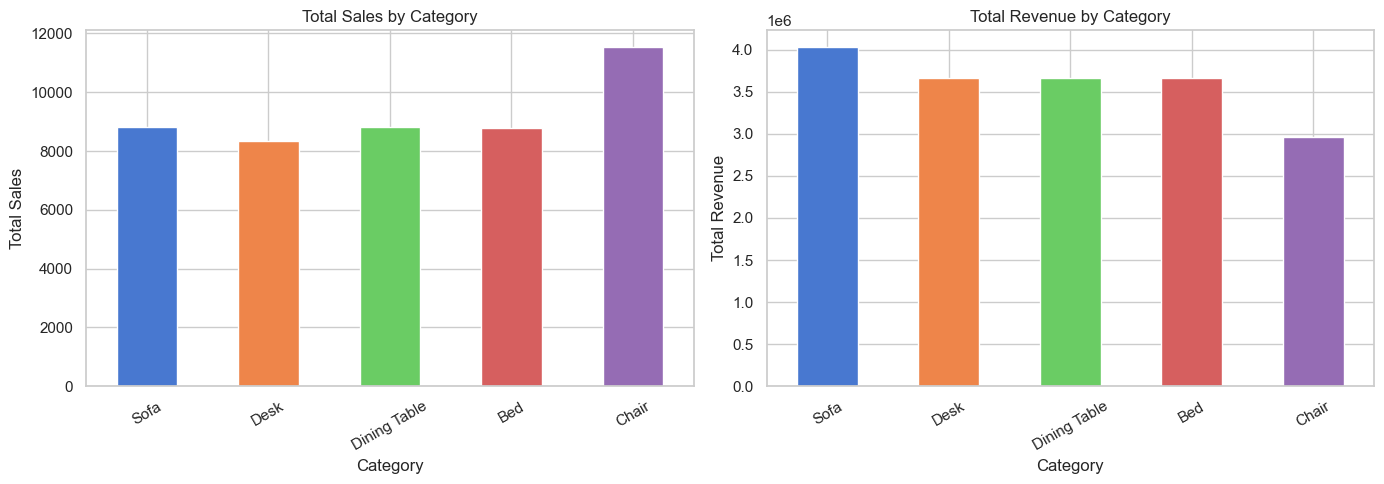

In [6]:
# ============================================================
# Step 6: Category sales & revenue analysis
# ============================================================
category_stats = df.groupby('category').agg(
    total_sales=('sales', 'sum'),
    total_revenue=('revenue', 'sum'),
    avg_sales=('sales', 'mean'),
    avg_revenue=('revenue', 'mean')
).sort_values('total_revenue', ascending=False)

display(category_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
category_stats['total_sales'].plot(kind='bar', ax=axes[0], color=sns.color_palette('muted', len(category_stats)))
axes[0].set_title('Total Sales by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Total Sales')
axes[0].tick_params(axis='x', rotation=30)

category_stats['total_revenue'].plot(kind='bar', ax=axes[1], color=sns.color_palette('muted', len(category_stats)))
axes[1].set_title('Total Revenue by Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Total Revenue')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

,total_sales,total_revenue,avg_sales,avg_revenue
material,,,,
Wood,16280,7242789,18.13,8065.47
Fabric,8483,3053421,19.06,6861.62
Metal,5955,2266750,18.10,6889.82
Marble,4323,1665790,17.50,6744.09
Leather,5544,1566610,21.83,6167.76
Glass,3479,1412000,17.14,6955.67
Plastic,2212,763093,17.84,6153.98


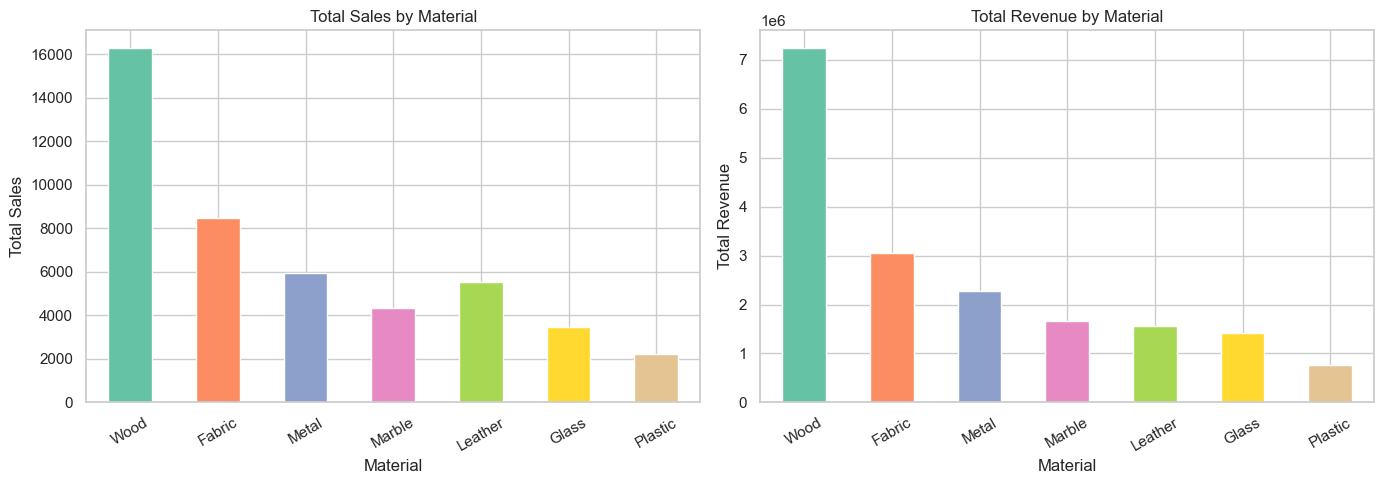

In [ ]:
# ============================================================
# Step 7: Material sales & revenue analysis
# ============================================================
material_stats = df.groupby('material').agg(
    total_sales=('sales', 'sum'),
    total_revenue=('revenue', 'sum'),
    avg_sales=('sales', 'mean'),
    avg_revenue=('revenue', 'mean')
).sort_values('total_revenue', ascending=False)

display(material_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
material_stats['total_sales'].plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2', len(material_stats)))
axes[0].set_title('Total Sales by Material')
axes[0].set_xlabel('Material')
axes[0].set_ylabel('Total Sales')
axes[0].tick_params(axis='x', rotation=30)

material_stats['total_revenue'].plot(kind='bar', ax=axes[1], color=sns.color_palette('Set2', len(material_stats)))
axes[1].set_title('Total Revenue by Material')
axes[1].set_xlabel('Material')
axes[1].set_ylabel('Total Revenue')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 3. Season & Location Analysis

In [8]:
# ============================================================
# Step 8: Season analysis
# ============================================================
season_stats = df.groupby('season').agg(
    total_sales=('sales', 'sum'),
    total_revenue=('revenue', 'sum'),
    avg_sales=('sales', 'mean'),
    avg_revenue=('revenue', 'mean')
).sort_values('total_sales', ascending=False)

display(season_stats)

,total_sales,total_revenue,avg_sales,avg_revenue
season,,,,
Winter,12304,4456790,18.90,6846.07
Fall,11752,4502425,18.05,6916.17
Spring,11575,4731304,18.85,7705.71
Summer,10645,4279934,18.23,7328.65


In [9]:
# ============================================================
# Step 9: Location analysis
# ============================================================
location_stats = df.groupby('location').agg(
    total_sales=('sales', 'sum'),
    total_revenue=('revenue', 'sum'),
    avg_sales=('sales', 'mean'),
    avg_revenue=('revenue', 'mean')
).sort_values('total_sales', ascending=False)

display(location_stats)

,total_sales,total_revenue,avg_sales,avg_revenue
location,,,,
Rural,17077,6767522,19.04,7544.62
Suburban,14746,5594812,18.14,6881.69
Urban,14453,5608119,18.29,7098.88


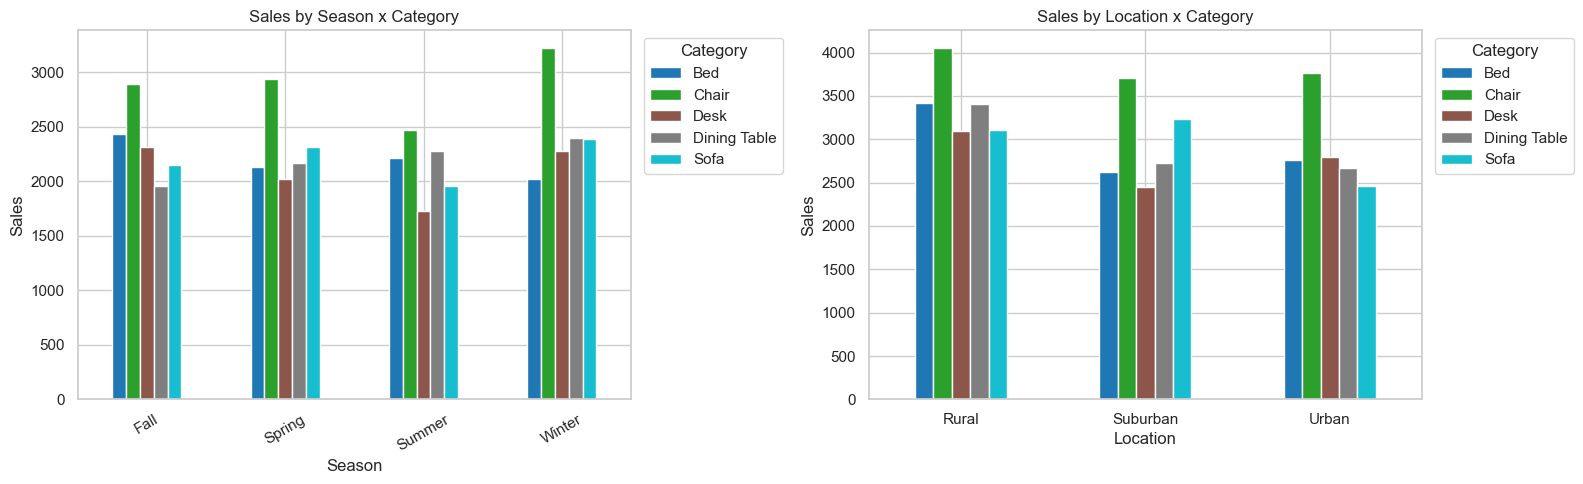

In [10]:
# ============================================================
# Step 10: Season x Category / Location x Category pivot analysis
# ============================================================
season_category = pd.pivot_table(df, values='sales', index='season', columns='category', aggfunc='sum')
location_category = pd.pivot_table(df, values='sales', index='location', columns='category', aggfunc='sum')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

season_category.plot(kind='bar', ax=axes[0], colormap='tab10')
axes[0].set_title('Sales by Season x Category')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Sales')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left')

location_category.plot(kind='bar', ax=axes[1], colormap='tab10')
axes[1].set_title('Sales by Location x Category')
axes[1].set_xlabel('Location')
axes[1].set_ylabel('Sales')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 4. Store Type Analysis

,total_sales,total_revenue,avg_sales,avg_revenue,avg_profit_margin,avg_delivery_days
store_type,,,,,,
Online,24362,9183051,18.64,7026.05,0.50,56.96
Retail,21914,8787402,18.37,7365.80,0.49,57.76


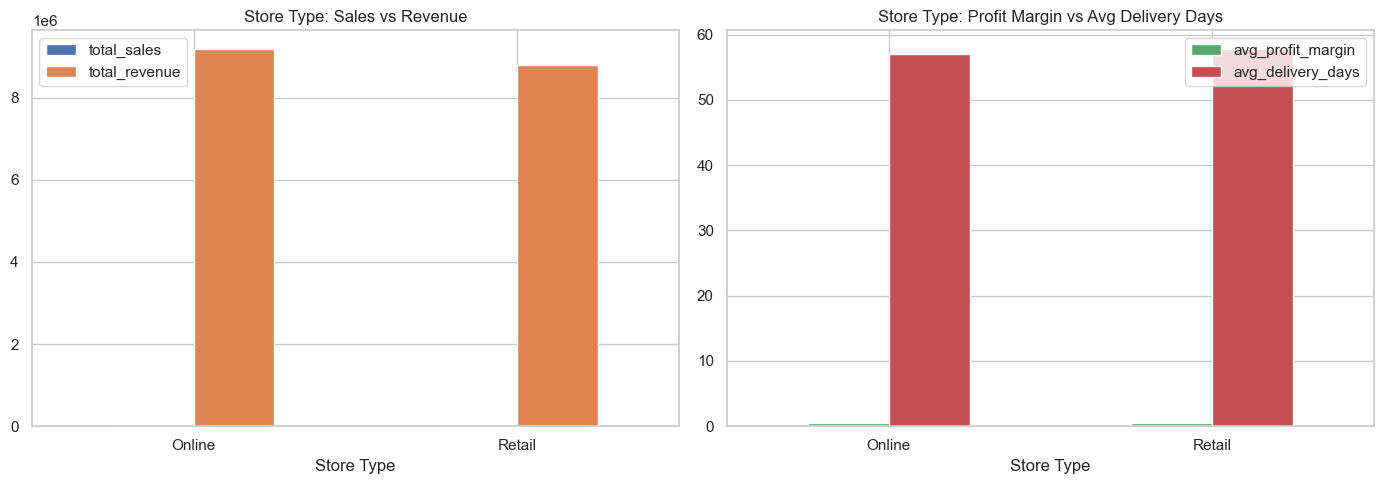

In [11]:
# ============================================================
# Step 11: Online vs Retail store comparison
# ============================================================
store_stats = df.groupby('store_type').agg(
    total_sales=('sales', 'sum'),
    total_revenue=('revenue', 'sum'),
    avg_sales=('sales', 'mean'),
    avg_revenue=('revenue', 'mean'),
    avg_profit_margin=('profit_margin', 'mean'),
    avg_delivery_days=('delivery_days', 'mean')
).sort_values('total_revenue', ascending=False)

display(store_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

store_stats[['total_sales', 'total_revenue']].plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Store Type: Sales vs Revenue')
axes[0].set_xlabel('Store Type')
axes[0].tick_params(axis='x', rotation=0)

store_stats[['avg_profit_margin', 'avg_delivery_days']].plot(kind='bar', ax=axes[1], color=['#55A868', '#C44E52'])
axes[1].set_title('Store Type: Profit Margin vs Avg Delivery Days')
axes[1].set_xlabel('Store Type')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 5. Profit Analysis

,avg_profit_margin,avg_cost_price_ratio,total_estimated_profit,avg_estimated_profit
category,,,,
Sofa,0.50,0.50,4028124,8254.35
Desk,0.52,0.48,3664253,7313.88
Dining Table,0.51,0.49,3662505,6871.49
Bed,0.51,0.49,3657871,7604.72
Chair,0.44,0.56,2957700,5951.11


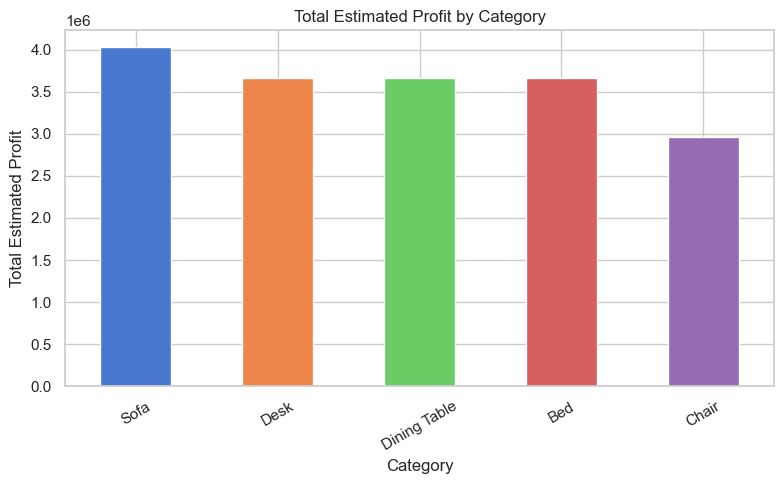

In [12]:
# ============================================================
# Step 12: Profit analysis by category
# ============================================================
profit_by_category = df.groupby('category').agg(
    avg_profit_margin=('profit_margin', 'mean'),
    avg_cost_price_ratio=('cost_price_ratio', 'mean'),
    total_estimated_profit=('estimated_profit', 'sum'),
    avg_estimated_profit=('estimated_profit', 'mean')
).sort_values('total_estimated_profit', ascending=False)

display(profit_by_category)

profit_by_category['total_estimated_profit'].plot(
    kind='bar', figsize=(8, 5), color=sns.color_palette('muted', len(profit_by_category))
)
plt.title('Total Estimated Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Estimated Profit')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# Step 13: Profit analysis by material
# ============================================================
profit_by_material = df.groupby('material').agg(
    avg_profit_margin=('profit_margin', 'mean'),
    avg_cost_price_ratio=('cost_price_ratio', 'mean'),
    total_estimated_profit=('estimated_profit', 'sum'),
    avg_estimated_profit=('estimated_profit', 'mean')
).sort_values('total_estimated_profit', ascending=False)

display(profit_by_material)

,avg_profit_margin,avg_cost_price_ratio,total_estimated_profit,avg_estimated_profit
material,,,,
Wood,0.55,0.45,7242789,8065.47
Fabric,0.47,0.53,3053421,6861.62
Metal,0.48,0.52,2266750,6889.82
Marble,0.49,0.51,1665790,6744.09
Leather,0.36,0.64,1566610,6167.76
Glass,0.50,0.50,1412000,6955.67
Plastic,0.50,0.50,763093,6153.98


In [14]:
# ============================================================
# Step 14: Top 10 highest profit-margin products
# ============================================================
high_profit_products = df.sort_values('profit_margin', ascending=False).head(10)
display(high_profit_products[
    ['category', 'material', 'color', 'store_type', 'location', 'price', 'cost', 'profit_margin', 'sales', 'revenue']
])

,category,material,color,store_type,location,price,cost,profit_margin,sales,revenue
2484,Sofa,Leather,Green,Retail,Urban,1877,152,0.92,33,56925
1994,Dining Table,Marble,Black,Retail,Rural,1960,186,0.91,1,1774
81,Bed,Wood,White,Retail,Suburban,1888,195,0.90,29,49097
1075,Desk,Wood,Brown,Retail,Rural,1370,160,0.88,26,31460
1178,Desk,Metal,Brown,Retail,Suburban,1314,158,0.88,20,23120
1517,Dining Table,Glass,Black,Online,Rural,1278,157,0.88,32,35872
354,Bed,Wood,White,Online,Urban,1308,164,0.87,11,12584
1735,Dining Table,Metal,Black,Retail,Suburban,1239,157,0.87,17,18394
262,Bed,Wood,White,Retail,Suburban,1401,179,0.87,17,20774
684,Chair,Wood,White,Online,Suburban,651,92,0.86,13,7267


In [15]:
# ============================================================
# Step 15: High-revenue but low-margin products (worth reviewing pricing/cost structure)
# ============================================================
high_rev_low_profit = df[
    (df['revenue'] >= df['revenue'].quantile(0.75)) &
    (df['profit_margin'] <= df['profit_margin'].quantile(0.25))
]
display(high_rev_low_profit[
    ['category', 'material', 'price', 'cost', 'sales', 'revenue', 'profit_margin']
].sort_values('revenue', ascending=False).head(10))

,category,material,price,cost,sales,revenue,profit_margin
2163,Sofa,Wood,3575,2283,25,32300,0.36
1487,Dining Table,Metal,1759,1126,43,27219,0.36
2318,Sofa,Wood,1794,1243,41,22591,0.31
69,Bed,Leather,1836,1130,30,21180,0.38
2040,Sofa,Wood,3343,2168,18,21150,0.35
2485,Sofa,Leather,1895,1186,27,19143,0.37
2077,Sofa,Fabric,3444,2223,15,18315,0.35
2038,Sofa,Fabric,3340,2243,16,17552,0.33
2073,Sofa,Fabric,5440,3430,8,16080,0.37
1579,Dining Table,Marble,1680,1095,27,15795,0.35


## 6. Inventory Risk Analysis

inventory_risk
Normal            2106
Overstock Risk     200
Stockout Risk      194
Name: count, dtype: int64

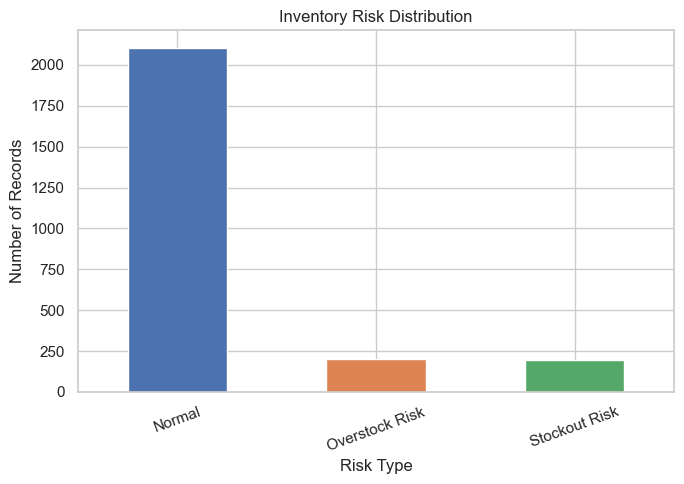

In [16]:
# ============================================================
# Step 16: Inventory risk classification (Overstock / Stockout / Normal)
# ============================================================
sales_high  = df['sales'].quantile(0.75)
sales_low   = df['sales'].quantile(0.25)
inv_high    = df['inventory'].quantile(0.75)
inv_low     = df['inventory'].quantile(0.25)

def classify_inventory(row):
    if row['inventory'] >= inv_high and row['sales'] <= sales_low:
        return 'Overstock Risk'   # high inventory, low sales -> overstock risk
    elif row['inventory'] <= inv_low and row['sales'] >= sales_high:
        return 'Stockout Risk'    # low inventory, high sales -> stockout risk
    else:
        return 'Normal'

df['inventory_risk'] = df.apply(classify_inventory, axis=1)

risk_summary = df['inventory_risk'].value_counts()
display(risk_summary)

risk_summary.plot(kind='bar', figsize=(7, 5), color=['#4C72B0', '#DD8452', '#55A868'])
plt.title('Inventory Risk Distribution')
plt.xlabel('Risk Type')
plt.ylabel('Number of Records')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# Step 17: Top 10 overstock risk products
# ============================================================
overstock = df[df['inventory_risk'] == 'Overstock Risk'].sort_values('inventory_sales_ratio', ascending=False)
display(overstock[
    ['category', 'material', 'location', 'store_type', 'inventory', 'sales', 'inventory_sales_ratio', 'profit_margin']
].head(10))

,category,material,location,store_type,inventory,sales,inventory_sales_ratio,profit_margin
2000,Dining Table,Metal,Suburban,Retail,10,0,10.00,0.32
558,Chair,Metal,Rural,Online,9,0,9.00,0.09
2005,Dining Table,Glass,Urban,Retail,9,0,9.00,0.63
476,Bed,Wood,Rural,Retail,9,0,9.00,0.46
2008,Dining Table,Glass,Urban,Online,9,0,9.00,0.64
479,Bed,Fabric,Suburban,Retail,8,0,8.00,0.59
474,Bed,Leather,Rural,Retail,8,0,8.00,0.38
477,Bed,Wood,Rural,Online,8,0,8.00,0.54
1475,Desk,Plastic,Rural,Online,8,0,8.00,0.49
582,Chair,Leather,Rural,Retail,8,0,8.00,0.26


In [18]:
# ============================================================
# Step 18: Top 10 stockout risk products
# ============================================================
stockout = df[df['inventory_risk'] == 'Stockout Risk'].sort_values('sales_inventory_ratio', ascending=False)
display(stockout[
    ['category', 'material', 'location', 'store_type', 'inventory', 'sales', 'sales_inventory_ratio', 'profit_margin']
].head(10))

,category,material,location,store_type,inventory,sales,sales_inventory_ratio,profit_margin
869,Chair,Leather,Rural,Retail,0,88,88.00,0.58
578,Chair,Fabric,Rural,Retail,0,85,85.00,0.63
980,Desk,Metal,Rural,Online,0,52,52.00,0.74
1479,Dining Table,Marble,Urban,Online,0,51,51.00,0.28
1480,Dining Table,Marble,Rural,Retail,0,49,49.00,0.65
984,Desk,Glass,Suburban,Online,0,47,47.00,0.01
985,Desk,Glass,Rural,Retail,0,46,46.00,0.50
976,Chair,Leather,Urban,Online,1,88,44.00,0.09
1485,Dining Table,Marble,Urban,Online,0,44,44.00,0.78
955,Chair,Leather,Urban,Online,0,42,42.00,0.18


In [19]:
# ============================================================
# Step 19: Inventory overview by category
# ============================================================
inventory_by_category = df.groupby('category').agg(
    total_inventory=('inventory', 'sum'),
    total_sales=('sales', 'sum'),
    avg_inventory=('inventory', 'mean'),
    avg_sales=('sales', 'mean'),
    avg_inventory_sales_ratio=('inventory_sales_ratio', 'mean')
).sort_values('avg_inventory_sales_ratio', ascending=False)

display(inventory_by_category)

,total_inventory,total_sales,avg_inventory,avg_sales,avg_inventory_sales_ratio
category,,,,,
Dining Table,2697,8806,5.06,16.52,0.66
Bed,2406,8798,5.00,18.29,0.54
Desk,2364,8338,4.72,16.64,0.53
Chair,2492,11526,5.01,23.19,0.43
Sofa,2400,8808,4.92,18.05,0.43


## 7. Delivery Analysis

,avg_delivery_days,median_delivery_days,max_delivery_days,order_count
location,,,,
Rural,57.37,57.00,90,897
Suburban,57.36,57.00,90,813
Urban,57.30,57.00,90,790


,avg_delivery_days,median_delivery_days,max_delivery_days,order_count
store_type,,,,
Retail,57.76,58.00,90,1193
Online,56.96,56.00,90,1307


,avg_delivery_days,median_delivery_days,max_delivery_days,order_count
category,,,,
Bed,57.96,57.00,90,481
Sofa,57.48,58.00,90,488
Chair,57.32,57.00,90,497
Desk,57.03,57.00,90,501
Dining Table,56.98,56.00,90,533


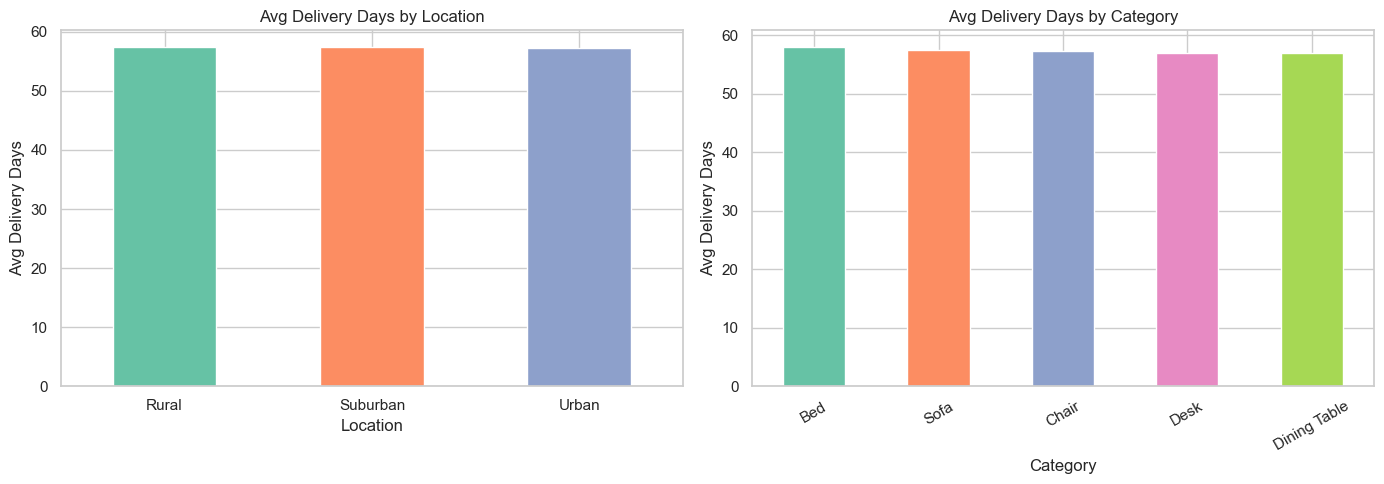

In [20]:
# ============================================================
# Step 20: Delivery days analysis across dimensions
# ============================================================
def delivery_agg(group_col):
    return df.groupby(group_col).agg(
        avg_delivery_days=('delivery_days', 'mean'),
        median_delivery_days=('delivery_days', 'median'),
        max_delivery_days=('delivery_days', 'max'),
        order_count=('delivery_days', 'count')
    ).sort_values('avg_delivery_days', ascending=False)

delivery_by_location   = delivery_agg('location')
delivery_by_store_type = delivery_agg('store_type')
delivery_by_category   = delivery_agg('category')

display(delivery_by_location)
display(delivery_by_store_type)
display(delivery_by_category)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
delivery_by_location['avg_delivery_days'].plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2', len(delivery_by_location)))
axes[0].set_title('Avg Delivery Days by Location')
axes[0].set_xlabel('Location')
axes[0].set_ylabel('Avg Delivery Days')
axes[0].tick_params(axis='x', rotation=0)

delivery_by_category['avg_delivery_days'].plot(kind='bar', ax=axes[1], color=sns.color_palette('Set2', len(delivery_by_category)))
axes[1].set_title('Avg Delivery Days by Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Avg Delivery Days')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# Step 21: Delivery delay risk (orders > 7 days flagged as delayed)
# ============================================================
df['delay_risk'] = np.where(df['delivery_days'] > 7, 1, 0)

delay_by_location = df.groupby('location').agg(
    delay_rate=('delay_risk', 'mean'),
    avg_delivery_days=('delivery_days', 'mean')
).sort_values('delay_rate', ascending=False)

display(delay_by_location)

,delay_rate,avg_delivery_days
location,,
Rural,1.00,57.37
Suburban,1.00,57.36
Urban,1.00,57.30


## 8. Correlation Analysis

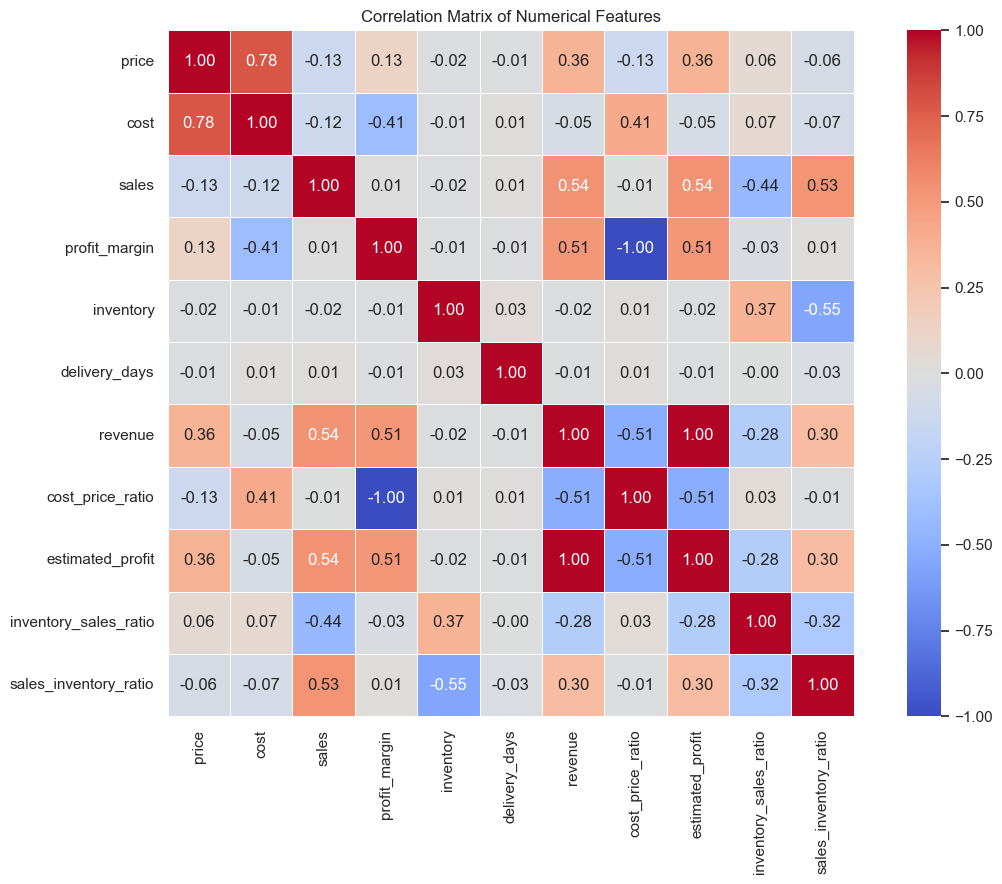

In [22]:
# ============================================================
# Step 22: Correlation heatmap (seaborn with annotated values)
# ============================================================
numeric_cols = [
    'price', 'cost', 'sales', 'profit_margin', 'inventory',
    'delivery_days', 'revenue', 'cost_price_ratio',
    'estimated_profit', 'inventory_sales_ratio', 'sales_inventory_ratio'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr,
    annot=True,          # show values in cells
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True
)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

## 9. Summary & Conclusions

In [23]:
# ============================================================
# Step 23: Key metrics summary
# ============================================================
print('=' * 50)
print('  Furniture Sales - Key Metrics Summary')
print('=' * 50)

print(f'\n[Category]')
print(f'  Highest sales: {category_stats["total_sales"].idxmax()}')
print(f'  Highest revenue: {category_stats["total_revenue"].idxmax()}')
print(f'  Highest profit: {profit_by_category["total_estimated_profit"].idxmax()}')

print(f'\n[Material]')
print(f'  Highest revenue: {material_stats["total_revenue"].idxmax()}')
print(f'  Highest profit: {profit_by_material["total_estimated_profit"].idxmax()}')

print(f'\n[Season & Location]')
print(f'  Peak sales season: {season_stats["total_sales"].idxmax()}')
print(f'  Highest sales location: {location_stats["total_sales"].idxmax()}')

print(f'\n[Store Type]')
print(f'  Highest revenue: {store_stats["total_revenue"].idxmax()}')

print(f'\n[Inventory Risk]')
print(f'  Overstock risk records: {(df["inventory_risk"] == "Overstock Risk").sum()}')
print(f'  Stockout risk records: {(df["inventory_risk"] == "Stockout Risk").sum()}')

print(f'\n[Delivery]')
print(f'  Slowest delivery location: {delivery_by_location["avg_delivery_days"].idxmax()}')
print(f'  Slowest delivery category: {delivery_by_category["avg_delivery_days"].idxmax()}')

  Furniture Sales - Key Metrics Summary

[Category]
  Highest sales: Chair
  Highest revenue: Sofa
  Highest profit: Sofa

[Material]
  Highest revenue: Wood
  Highest profit: Wood

[Season & Location]
  Peak sales season: Winter
  Highest sales location: Rural

[Store Type]
  Highest revenue: Online

[Inventory Risk]
  Overstock risk records: 200
  Stockout risk records: 194

[Delivery]
  Slowest delivery location: Rural
  Slowest delivery category: Bed


### Business Insights

Key takeaways from the analysis:

1. **Category priority**: Top-performing categories by revenue and profit should be the primary focus for promotions. High-revenue but low-margin products (Step 15) warrant a review of pricing or cost structure.

2. **Material strategy**: Some materials command higher prices but have limited sales volume. Evaluate SKU rationalization based on both margin and total contribution.

3. **Seasonal stocking**: Build up inventory ahead of peak seasons. Pay close attention to the stockout risk product list (Step 18).

4. **Inventory management**: Consider promotional clearance for overstock items. Prioritize replenishment or capacity expansion for stockout-risk products.

5. **Delivery optimization**: For locations and categories with significantly longer delivery times, evaluate introducing regional warehouses or renegotiating logistics partnerships.

6. **Channel strategy**: Online and retail channels differ in margin and delivery efficiency. Develop channel-specific operational strategies accordingly.